# Assignment 3: Cross-Species Foundation Models for Transcription Factors

#### Siva Satvik Mandapati - sm12779

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import random
import os

from pathlib import Path

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


## 1. Build the Multi-Species TF Dataset
### 1.1 Retrieve TF gene sets

In [27]:
import mygene
import requests
import time

GO_TERMS = [
    "GO:0003702" # Changed from GO:0003700 to GO:0003702 for more specific TF activity
]
SPECIES_ORDER = [
    "human",
    "mouse",
    "fruitfly"
]
SPECIES_CODES = {
    "human": "homo_sapiens",
    "mouse": "mus_musculus",
    "fruitfly": "drosophila_melanogaster",
}

MG = mygene.MyGeneInfo()

def fetch_tf_genes(species: str, max_genes: int) -> pd.DataFrame:
    # Use a keyword search for 'transcription factor' if go.id query isn't working
    query_string = 'transcription factor'
    res = MG.query(
        q=query_string,
        species=species,
        fields="symbol,name,entrezgene,ensembl.gene", # Removed go.MF as we won't filter by it here
        # Removed size parameter to avoid 400 Bad Request
    )
    hits = res.get("hits", [])
    print(f"[DEBUG] mygene.query for TF genes ({species}) returned {len(hits)} raw hits with keyword search.")

    rows = []
    for i, hit in enumerate(hits):
        # Add debug prints to inspect hit structure
        if i < 3: # Only print for the first 3 hits to avoid excessive output
            print(f"  [DEBUG_HIT] Processing hit {i+1} for {species} (Symbol: {hit.get('symbol')}, Entrez: {hit.get('entrezgene')})")
            print(f"    [DEBUG_HIT] Raw hit structure: {hit}")

        ensembl_entries = hit.get("ensembl")
        if isinstance(ensembl_entries, dict):
            ensembl_entries = [ensembl_entries]

        if i < 3: # Debug print for ensembl entries
            print(f"    [DEBUG_HIT] Extracted Ensembl entries: {ensembl_entries}")

        found_ensembl_gene = False
        for entry in ensembl_entries or []:
            gene_id = entry.get("gene")
            if i < 3: # Debug print for gene_id
                print(f"      [DEBUG_HIT] Current Ensembl gene_id candidate: {gene_id}")

            if not gene_id:
                continue
            rows.append({
                "species": species,
                "symbol": hit.get("symbol"),
                "name": hit.get("name"),
                "entrez": hit.get("entrezgene"),
                "ensembl_gene_id": gene_id,
                "is_tf": 1,
            })
            found_ensembl_gene = True
            break # Take the first valid Ensembl gene_id

        if i < 3 and not found_ensembl_gene: # Debug if no gene_id was found for a hit
            print(f"    [DEBUG_HIT] No valid Ensembl gene_id found for hit {i+1} ({hit.get('symbol')}).")

    print(f"  [DEBUG] fetch_tf_genes for {species}: rows list length before DataFrame creation: {len(rows)}") # New debug print
    df = pd.DataFrame(rows).drop_duplicates("ensembl_gene_id")
    if len(df) > max_genes:
        df = df.sample(max_genes, random_state=SEED)
    return df

### 1.2 Sample non‑TF genes

In [28]:
def sample_non_tf_genes(species: str, n_samples: int) -> pd.DataFrame:
    # Query for general genes using a broad keyword search, then filter out TFs
    res = MG.query(
        q='gene', # Changed from 'go.id:"GO:0003674"' to a broad keyword search 'gene'
        species=species,
        fields="symbol,name,entrezgene,ensembl.gene,go.MF",
        # Removed size parameter to avoid 400 Bad Request
    )
    hits = res.get("hits", [])
    print(f"[DEBUG] mygene.query for non-TF genes ({species}) returned {len(hits)} raw hits from broad 'gene' query.")
    rows = []
    for hit in hits:
        go_field = hit.get("go")
        mf_entries = go_field.get("MF", []) if isinstance(go_field, dict) else []
        go_terms_ids = {entry.get("id") for entry in mf_entries if isinstance(entry, dict)}

        # Ensure it's not a TF by checking against GO_TERMS
        if go_terms_ids.intersection(GO_TERMS): # if it has any TF-related GO term, skip it
            continue

        ensembl_entries = hit.get("ensembl")
        if isinstance(ensembl_entries, dict):
            ensembl_entries = [ensembl_entries]

        for entry in ensembl_entries or []:
            gene_id = entry.get("gene")
            if not gene_id:
                continue
            rows.append({
                "species": species,
                "symbol": hit.get("symbol"),
                "name": hit.get("name"),
                "entrez": hit.get("entrezgene"),
                "ensembl_gene_id": gene_id,
                "is_tf": 0,
            })
    print(f"  [DEBUG] sample_non_tf_genes for {species}: rows list length before DataFrame creation: {len(rows)}") # New debug print
    df = pd.DataFrame(rows).drop_duplicates("ensembl_gene_id")
    if len(df) > n_samples:
        df = df.sample(n_samples, random_state=SEED)
    return df

### 1.3 Retrieve promoter, CDS, and protein sequences

In [5]:
def fetch_gene_metadata(ensembl_gene_id: str):
    url = f"https://rest.ensembl.org/lookup/id/{ensembl_gene_id}?expand=1"
    resp = requests.get(url, headers={"Content-Type": "application/json"})
    return resp.json() if resp.ok else None


def fetch_sequence(url: str):
    resp = requests.get(url, headers={"Content-Type": "text/plain"})
    return resp.text.strip() if resp.ok else None


def build_sequences(df, species, promoter_flank=2000, throttle_sec=0.2):
    rows = []
    for _, row in df.iterrows():
        meta = fetch_gene_metadata(row["ensembl_gene_id"])
        if not meta:
            continue

        chrom = meta.get("seq_region_name")
        strand = meta.get("strand", 1)
        tss = meta.get("start") if strand == 1 else meta.get("end")

        start = max(1, tss - promoter_flank)
        end = tss + promoter_flank

        promoter_url = (
            f"https://rest.ensembl.org/sequence/region/"
            f"{SPECIES_CODES[species]}/{chrom}:{start}..{end}:{strand}"
        )
        promoter_seq = fetch_sequence(promoter_url)

        canonical = next((tx for tx in meta.get("Transcript", []) if tx.get("is_canonical")), None)
        if not canonical:
            continue

        transcript_id = canonical.get("id")
        cds_seq = fetch_sequence(f"https://rest.ensembl.org/sequence/id/{transcript_id}?type=cds")

        protein_id = (canonical.get("Translation") or {}).get("id")
        protein_seq = fetch_sequence(f"https://rest.ensembl.org/sequence/id/{protein_id}?type=protein")

        if not cds_seq or not protein_seq:
            continue

        rows.append({
            "species": species,
            "symbol": row["symbol"],
            "ensembl_gene_id": row["ensembl_gene_id"],
            "is_tf": row["is_tf"],
            "cds_seq": cds_seq,
            "protein_seq": protein_seq,
            "chrom": chrom,
            "strand": strand,
        })

        time.sleep(throttle_sec)

    return pd.DataFrame(rows)

### 1.4 Build full dataset

In [29]:
def build_tf_dataset(per_species_limit=300, promoter_flank=2000, throttle_sec=0.2):
    records = []

    for species in SPECIES_ORDER:
        print(f"[DEBUG] Fetching TF genes for {species}...")
        tf_df = fetch_tf_genes(species, per_species_limit)
        print(f"[DEBUG] Found {len(tf_df)} TF genes for {species}.")

        print(f"[DEBUG] Sampling non-TF genes for {species}...")
        non_tf_df = sample_non_tf_genes(species, len(tf_df)) # Ensure n_samples is not 0 if tf_df is empty
        print(f"[DEBUG] Found {len(non_tf_df)} non-TF genes for {species}.")

        if tf_df.empty and non_tf_df.empty:
            print(f"[INFO] {species}: No TF or non-TF genes found to combine. Skipping sequence building.")
            continue

        combined = pd.concat([tf_df, non_tf_df], ignore_index=True)
        print(f"[DEBUG] Combined {len(combined)} genes for {species}.")

        print(f"[DEBUG] Building sequences for {species}...")
        seq_df = build_sequences(combined, species, promoter_flank, throttle_sec)
        print(f"[INFO] {species}: collected {len(seq_df)} genes with sequences.")
        records.append(seq_df)

    if not records:
        print("[WARNING] No records collected across all species.")
        return pd.DataFrame() # Return empty DataFrame if no records

    dataset = pd.concat(records, ignore_index=True)
    dataset.to_parquet(DATA_DIR / "tf_multispecies_sequences.parquet", index=False)
    return dataset

dataset = build_tf_dataset()
dataset.head()

[DEBUG] Fetching TF genes for human...


[DEBUG] mygene.query for TF genes (human) returned 10 raw hits with keyword search.
  [DEBUG_HIT] Processing hit 1 for human (Symbol: TCF23, Entrez: 150921)
    [DEBUG_HIT] Raw hit structure: {'_id': '150921', '_score': 53.327084, 'ensembl': {'gene': 'ENSG00000163792'}, 'entrezgene': '150921', 'name': 'transcription factor 23', 'symbol': 'TCF23'}
    [DEBUG_HIT] Extracted Ensembl entries: [{'gene': 'ENSG00000163792'}]
      [DEBUG_HIT] Current Ensembl gene_id candidate: ENSG00000163792
  [DEBUG_HIT] Processing hit 2 for human (Symbol: YY1, Entrez: 7528)
    [DEBUG_HIT] Raw hit structure: {'_id': '7528', '_score': 53.327084, 'ensembl': {'gene': 'ENSG00000100811'}, 'entrezgene': '7528', 'name': 'YY1 transcription factor', 'symbol': 'YY1'}
    [DEBUG_HIT] Extracted Ensembl entries: [{'gene': 'ENSG00000100811'}]
      [DEBUG_HIT] Current Ensembl gene_id candidate: ENSG00000100811
  [DEBUG_HIT] Processing hit 3 for human (Symbol: SP6, Entrez: 80320)
    [DEBUG_HIT] Raw hit structure: {'_id'

[INFO] human: collected 10 genes with sequences.
[DEBUG] Fetching TF genes for mouse...


[DEBUG] mygene.query for TF genes (mouse) returned 10 raw hits with keyword search.
  [DEBUG_HIT] Processing hit 1 for mouse (Symbol: Tcf23, Entrez: 69852)
    [DEBUG_HIT] Raw hit structure: {'_id': '69852', '_score': 44.72615, 'ensembl': {'gene': 'ENSMUSG00000006642'}, 'entrezgene': '69852', 'name': 'transcription factor 23', 'symbol': 'Tcf23'}
    [DEBUG_HIT] Extracted Ensembl entries: [{'gene': 'ENSMUSG00000006642'}]
      [DEBUG_HIT] Current Ensembl gene_id candidate: ENSMUSG00000006642
  [DEBUG_HIT] Processing hit 2 for mouse (Symbol: Tcf19, Entrez: 106795)
    [DEBUG_HIT] Raw hit structure: {'_id': '106795', '_score': 44.72615, 'ensembl': {'gene': 'ENSMUSG00000050410'}, 'entrezgene': '106795', 'name': 'transcription factor 19', 'symbol': 'Tcf19'}
    [DEBUG_HIT] Extracted Ensembl entries: [{'gene': 'ENSMUSG00000050410'}]
      [DEBUG_HIT] Current Ensembl gene_id candidate: ENSMUSG00000050410
  [DEBUG_HIT] Processing hit 3 for mouse (Symbol: Erg, Entrez: 13876)
    [DEBUG_HIT] Raw

[INFO] mouse: collected 11 genes with sequences.
[DEBUG] Fetching TF genes for fruitfly...


[DEBUG] mygene.query for TF genes (fruitfly) returned 10 raw hits with keyword search.
  [DEBUG_HIT] Processing hit 1 for fruitfly (Symbol: Tfb5, Entrez: 7354403)
    [DEBUG_HIT] Raw hit structure: {'_id': '7354403', '_score': 34.40457, 'ensembl': {'gene': 'FBgn0265968'}, 'entrezgene': '7354403', 'name': 'Transcription factor B5', 'symbol': 'Tfb5'}
    [DEBUG_HIT] Extracted Ensembl entries: [{'gene': 'FBgn0265968'}]
      [DEBUG_HIT] Current Ensembl gene_id candidate: FBgn0265968
  [DEBUG_HIT] Processing hit 2 for fruitfly (Symbol: TfIIFalpha, Entrez: 40790)
    [DEBUG_HIT] Raw hit structure: {'_id': '40790', '_score': 34.40457, 'ensembl': {'gene': 'FBgn0010282'}, 'entrezgene': '40790', 'name': 'Transcription factor IIFalpha', 'symbol': 'TfIIFalpha'}
    [DEBUG_HIT] Extracted Ensembl entries: [{'gene': 'FBgn0010282'}]
      [DEBUG_HIT] Current Ensembl gene_id candidate: FBgn0010282
  [DEBUG_HIT] Processing hit 3 for fruitfly (Symbol: TfIIEbeta, Entrez: 38527)
    [DEBUG_HIT] Raw hit st

,species,symbol,ensembl_gene_id,is_tf,cds_seq,protein_seq,chrom,strand
0,human,TCF23,ENSG00000163792,1,ATGTCACAGAGGAAGGCCAGAGGGCCACCAGCCATGCCAGGGGTGG...,MSQRKARGPPAMPGVGHSQTQAKARLLPGADRKRSRLSRTRQDPWE...,2,1
1,human,YY1,ENSG00000100811,1,ATGGCCTCGGGCGACACCCTCTACATCGCCACGGACGGCTCGGAGA...,MASGDTLYIATDGSEMPAEIVELHEIEVETIPVETIETTVVGEEEE...,14,1
2,human,SP6,ENSG00000189120,1,ATGCTAACCGCTGTCTGCGGCTCTCTGGGCAGCCAGCACACGGAAG...,MLTAVCGSLGSQHTEAPHASPPRLDLQPLQTYQGHTSPEAGDYPSP...,17,-1
3,human,TCF24,ENSG00000261787,1,ATGGACCGCGGCCGCCCAGCGGGCAGCCCCCTCAGCGCCAGCGCCG...,MDRGRPAGSPLSASAEPAPLAAAIRDSRPGRTGPGPAGPGGGSRSG...,8,-1
4,human,TCF4,ENSG00000196628,1,ATGCATCACCAACAGCGAATGGCTGCCTTAGGGACGGACAAAGAGC...,MHHQQRMAALGTDKELSDLLDFSAMFSPPVSSGKNGPTSLASGHFT...,18,-1


## 1.5 Dataset Statistics + Visualizations
Length distributions

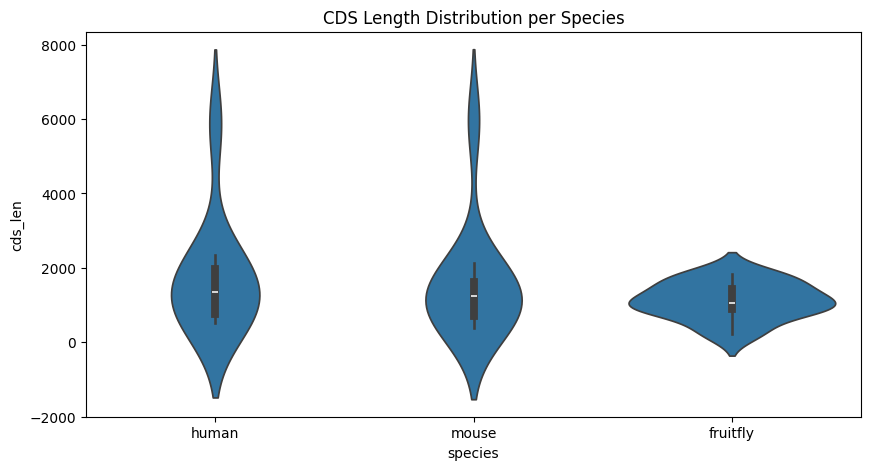

In [30]:
dataset["cds_len"] = dataset["cds_seq"].str.len()
dataset["protein_len"] = dataset["protein_seq"].str.len()

plt.figure(figsize=(10,5))
sns.violinplot(data=dataset, x="species", y="cds_len")
plt.title("CDS Length Distribution per Species")
plt.show()


GC content

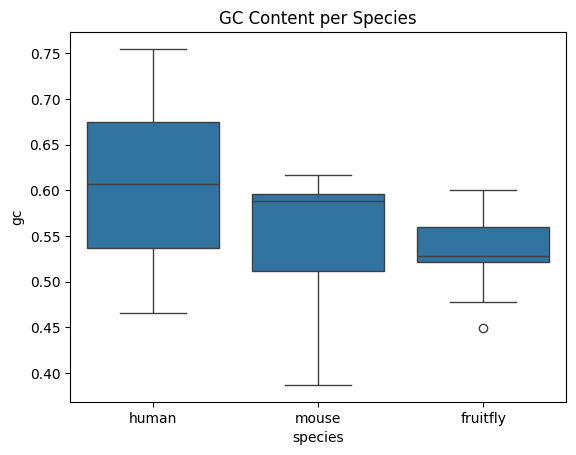

In [32]:
def gc_content(seq):
    seq = seq.upper()
    return (seq.count("G") + seq.count("C")) / len(seq)

dataset["gc"] = dataset["cds_seq"].apply(gc_content)

sns.boxplot(data=dataset, x="species", y="gc")
plt.title("GC Content per Species")
plt.show()


## 1.6 Train/Val/Test Splits

In [33]:
splits = {}

# Split 1: Human-focused
human_idx = dataset.index[dataset["species"] == "human"]
mouse_idx = dataset.index[dataset["species"] == "mouse"]
fly_idx = dataset.index[dataset["species"] == "fruitfly"]

splits["split1_train"] = human_idx.tolist()
splits["split1_val"] = human_idx.tolist()
splits["split1_test"] = mouse_idx.tolist() + fly_idx.tolist()

# Split 2: Mouse few-shot
fewshot = mouse_idx[:50]
splits["split2_train"] = human_idx.tolist() + fewshot.tolist()
splits["split2_val"] = fewshot.tolist()
splits["split2_test"] = list(mouse_idx[50:]) + fly_idx.tolist()

# Split 3: Fly hold-out
splits["split3_train"] = human_idx.tolist() + mouse_idx.tolist()
splits["split3_val"] = human_idx.tolist() + mouse_idx.tolist()
splits["split3_test"] = fly_idx.tolist()

import json
with open(DATA_DIR / "tf_split_indices.json", "w") as f:
    json.dump(splits, f, indent=2)

## 2. DNA / Protein Foundation Model Embeddings

### 2.1 Nucleotide Transformer (CDS embeddings)

In [34]:
from transformers import AutoTokenizer, AutoModel

dna_model_name = "InstaDeepAI/nucleotide-transformer-500m-multi-species"

dna_tokenizer = AutoTokenizer.from_pretrained(dna_model_name, trust_remote_code=True)
dna_model = AutoModel.from_pretrained(dna_model_name, trust_remote_code=True).eval().cuda()

def embed_dna(seq):
    tokens = dna_tokenizer(seq, return_tensors="pt", truncation=True, max_length=1024)
    tokens = {k: v.cuda() for k, v in tokens.items()}
    with torch.no_grad():
        out = dna_model(**tokens).last_hidden_state.mean(dim=1)
    return out.cpu().numpy().flatten()

dna_embeddings = np.vstack([embed_dna(seq) for seq in dataset["cds_seq"]])
np.save(DATA_DIR / "dna_embeddings.npy", dna_embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


OSError: InstaDeepAI/nucleotide-transformer-500m-multi-species is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

### 2.2 Protein embeddings (ESM2)

In [ ]:
protein_model_name = "facebook/esm2_t33_650M_UR50D"

prot_tokenizer = AutoTokenizer.from_pretrained(protein_model_name)
prot_model = AutoModel.from_pretrained(protein_model_name).eval().cuda()

def embed_protein(seq):
    tokens = prot_tokenizer(seq, return_tensors="pt", truncation=True, max_length=1024)
    tokens = {k: v.cuda() for k, v in tokens.items()}
    with torch.no_grad():
        out = prot_model(**tokens).last_hidden_state.mean(dim=1)
    return out.cpu().numpy().flatten()

protein_embeddings = np.vstack([embed_protein(seq) for seq in dataset["protein_seq"]])
np.save(DATA_DIR / "protein_embeddings.npy", protein_embeddings)

## 3. Baselines + Classifiers

### 3.1 BiLSTM CDS baseline

In [35]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs = seqs
        self.labels = labels

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        seq = torch.tensor([ord(c) % 20 for c in seq[:500]], dtype=torch.long)
        return seq, torch.tensor(self.labels[idx], dtype=torch.float32)

class BiLSTM(nn.Module):
    def __init__(self, vocab=20, emb=32, hidden=64):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb)
        self.lstm = nn.LSTM(emb, hidden, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden*2, 1)

    def forward(self, x):
        x = self.emb(x)
        _, (h, _) = self.lstm(x)
        h = torch.cat([h[0], h[1]], dim=-1)
        return torch.sigmoid(self.fc(h))

### 3.2 k‑mer + AA composition baselines

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

def kmer_counts(seq, k=3):
    from collections import Counter
    kmers = [seq[i:i+k] for i in range(len(seq)-k+1)]
    c = Counter(kmers)
    total = sum(c.values())
    return {k: v/total for k, v in c.items()}

X_kmer = pd.DataFrame([kmer_counts(s) for s in dataset["cds_seq"]]).fillna(0)
y = dataset["is_tf"].values

clf = LogisticRegression(max_iter=2000)
clf.fit(X_kmer.loc[splits["split1_train"]], y[splits["split1_train"]])

pred = clf.predict_proba(X_kmer.loc[splits["split1_test"]])[:,1]
print("ROC-AUC:", roc_auc_score(y[splits["split1_test"]], pred))

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

### 3.3 FM Embedding Classifiers

In [ ]:
from sklearn.neural_network import MLPClassifier

dna_emb = np.load(DATA_DIR / "dna_embeddings.npy")
prot_emb = np.load(DATA_DIR / "protein_embeddings.npy")

clf_dna = MLPClassifier(hidden_layer_sizes=(128,), max_iter=200)
clf_dna.fit(dna_emb[splits["split1_train"]], y[splits["split1_train"]])

clf_prot = MLPClassifier(hidden_layer_sizes=(128,), max_iter=200)
clf_prot.fit(prot_emb[splits["split1_train"]], y[splits["split1_train"]])

## 4. PCA + UMAP Visualizations

In [37]:
from sklearn.decomposition import PCA
import umap

pca = PCA(n_components=50).fit(prot_emb)
emb_50 = pca.transform(prot_emb)

u = umap.UMAP(n_neighbors=20, min_dist=0.1).fit_transform(emb_50)

plt.figure(figsize=(8,6))
sns.scatterplot(x=u[:,0], y=u[:,1], hue=dataset["species"])
plt.title("UMAP of Protein Embeddings")
plt.show()

NameError: name 'prot_emb' is not defined

## 5. Discussion Section